In [1]:
    # dependencies
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np

In [7]:
# settings
bond_type = "pb"
experiment = 13
kn_ks = 1

In [12]:
# getting data
# Physics Sim
plt.close('all')
fig = plt.figure(figsize=(39,28), constrained_layout=True)
fig.suptitle(f'Experiments 1-{experiment}, kn/ks = {kn_ks}', fontsize=16)
gs = fig.add_gridspec(9, experiment)
mark = ""

for i in range(0,experiment):
    if bond_type == "cb":
        df = pd.read_csv(f"experiment_{i+1}_{kn_ks}.csv",delimiter=",")
    elif bond_type == "ch":
        df = pd.read_csv(f"Chain_{i+1}.csv",delimiter=",")
    elif bond_type == "pbt":
        df = pd.read_csv(f"TEXP_{i+1}.csv",delimiter=",")
    else: 
        df = pd.read_csv(f"{bond_type}_experiment_{i+1}_{kn_ks}.csv",delimiter=",")

    df = df.astype(float)
    
    df["Timestamp"] = df["Timestamp"] - df.at[df.index[0], "Timestamp"]
    df["Timestamp"] = df["Timestamp"] - df["Timestamp"][1]

    # PFC
    if bond_type == "pbt":
        df2 = pd.read_fwf(f"histories/pb-tear_experiment_{i+1}_{kn_ks}.his",delimiter=" ")
    elif bond_type == "ch":
        df2 = pd.read_csv(f"Chain_T_{i+1}.csv",delimiter=",")
    else: 
        df2 = pd.read_fwf(f"histories/{bond_type}-fric_experiment_{i+1}_{kn_ks}.his",delimiter=" ")
    df2 = df2.drop(df2.index[0])
    df2 = df2.astype(float)
    df2.columns = ["Step", 
                "Time(s)", 
                "x_pos", 
                "y_pos", 
                "theta", 
                "x_vel", 
                "y_vel", 
                "omega", 
                "c_nforce", 
                "c_sforce", 
                "c_moment", 
                "c_normal_y_dir", 
                "c_normal_x_dir",
                "c_pos_y",
                "c_pos_x"]
        
    df2["Time(s)"] = df2["Time(s)"] - df2.at[df2.index[0], "Time(s)"]

    # X Position
    ax1 = fig.add_subplot(gs[0, i])
    ax1.set_ylabel('Position (m)')
    ax1.plot(df["Timestamp"], df["X Position"], marker=mark)

    ax1.plot(df2["Time(s)"], df2["x_pos"])
    ax1.set_title('X')

    # X Velocity
    ax2 = fig.add_subplot(gs[1, i])
    ax2.set_ylabel('Velocity (m)')
    ax2.plot(df["Timestamp"], df["X Velocity"], marker=mark)
    ax2.plot(df2["Time(s)"], df2["x_vel"])
    ax2.set_title('X Velocity')

    # Normal Force
    ax3 = fig.add_subplot(gs[2, i])
    ax3.set_ylabel('Force (N/m)')
    ax3.plot(df["Timestamp"], df["Data1"], marker=mark)
    ax3.plot(df2["Time(s)"], df2["c_nforce"])
    ax3.set_title('Normal Force')

    # Y Position
    ax4 = fig.add_subplot(gs[3, i])
    ax4.set_ylabel('Position (m)')
    ax4.plot(df["Timestamp"], df["Y Position"], marker=mark)
    ax4.plot(df2["Time(s)"], df2["y_pos"])
    ax4.set_title('Y')

    # Y Velocity
    ax5 = fig.add_subplot(gs[4, i])
    ax5.set_ylabel('Velocity (m)')
    ax5.plot(df["Timestamp"], df["Y Velocity"], marker=mark)
    ax5.plot(df2["Time(s)"], df2["y_vel"])
    ax5.set_title('Y Velocity')

    # Shear Force
    ax6 = fig.add_subplot(gs[5, i])
    ax6.set_ylabel('Force (N/m)')
    ax6.plot(df["Timestamp"], df["Data2"].apply(abs), marker=mark)
    ax6.plot(df2["Time(s)"], df2["c_sforce"])
    ax6.set_title('Shear Force')

    # Theta
    ax7 = fig.add_subplot(gs[6, i])
    ax7.set_ylabel('Position (m)')
    ax7.plot(df["Timestamp"], df["Rotation"] * (180/3.14159), marker=mark)
    ax7.plot(df2["Time(s)"], df2["theta"])
    ax7.set_title('Theta')

    # Omega
    ax8 = fig.add_subplot(gs[7, i])
    ax8.set_ylabel('Velocity (m)')
    ax8.plot(df["Timestamp"], df["Rotation Velocity"], marker=mark)
    ax8.plot(df2["Time(s)"], df2["omega"])
    ax8.set_title('Omega')

    # Moment
    ax9 = fig.add_subplot(gs[8, i])
    ax9.set_ylabel('N*m')
    ax9.plot(df["Timestamp"], df["Data3"], marker=mark)
    ax9.plot(df2["Time(s)"], df2["c_moment"])
    ax9.set_title('Moment')

    # Moment
    # ax10 = fig.add_subplot(gs[9, i])
    # ax10.set_ylabel('N*m')
    # ax10.plot(df["Timestamp"], df["Data3"] + df["Data1"], marker=mark)
    # ax10.set_title('Moment')

    ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax7.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax8.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax9.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    # ax10.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

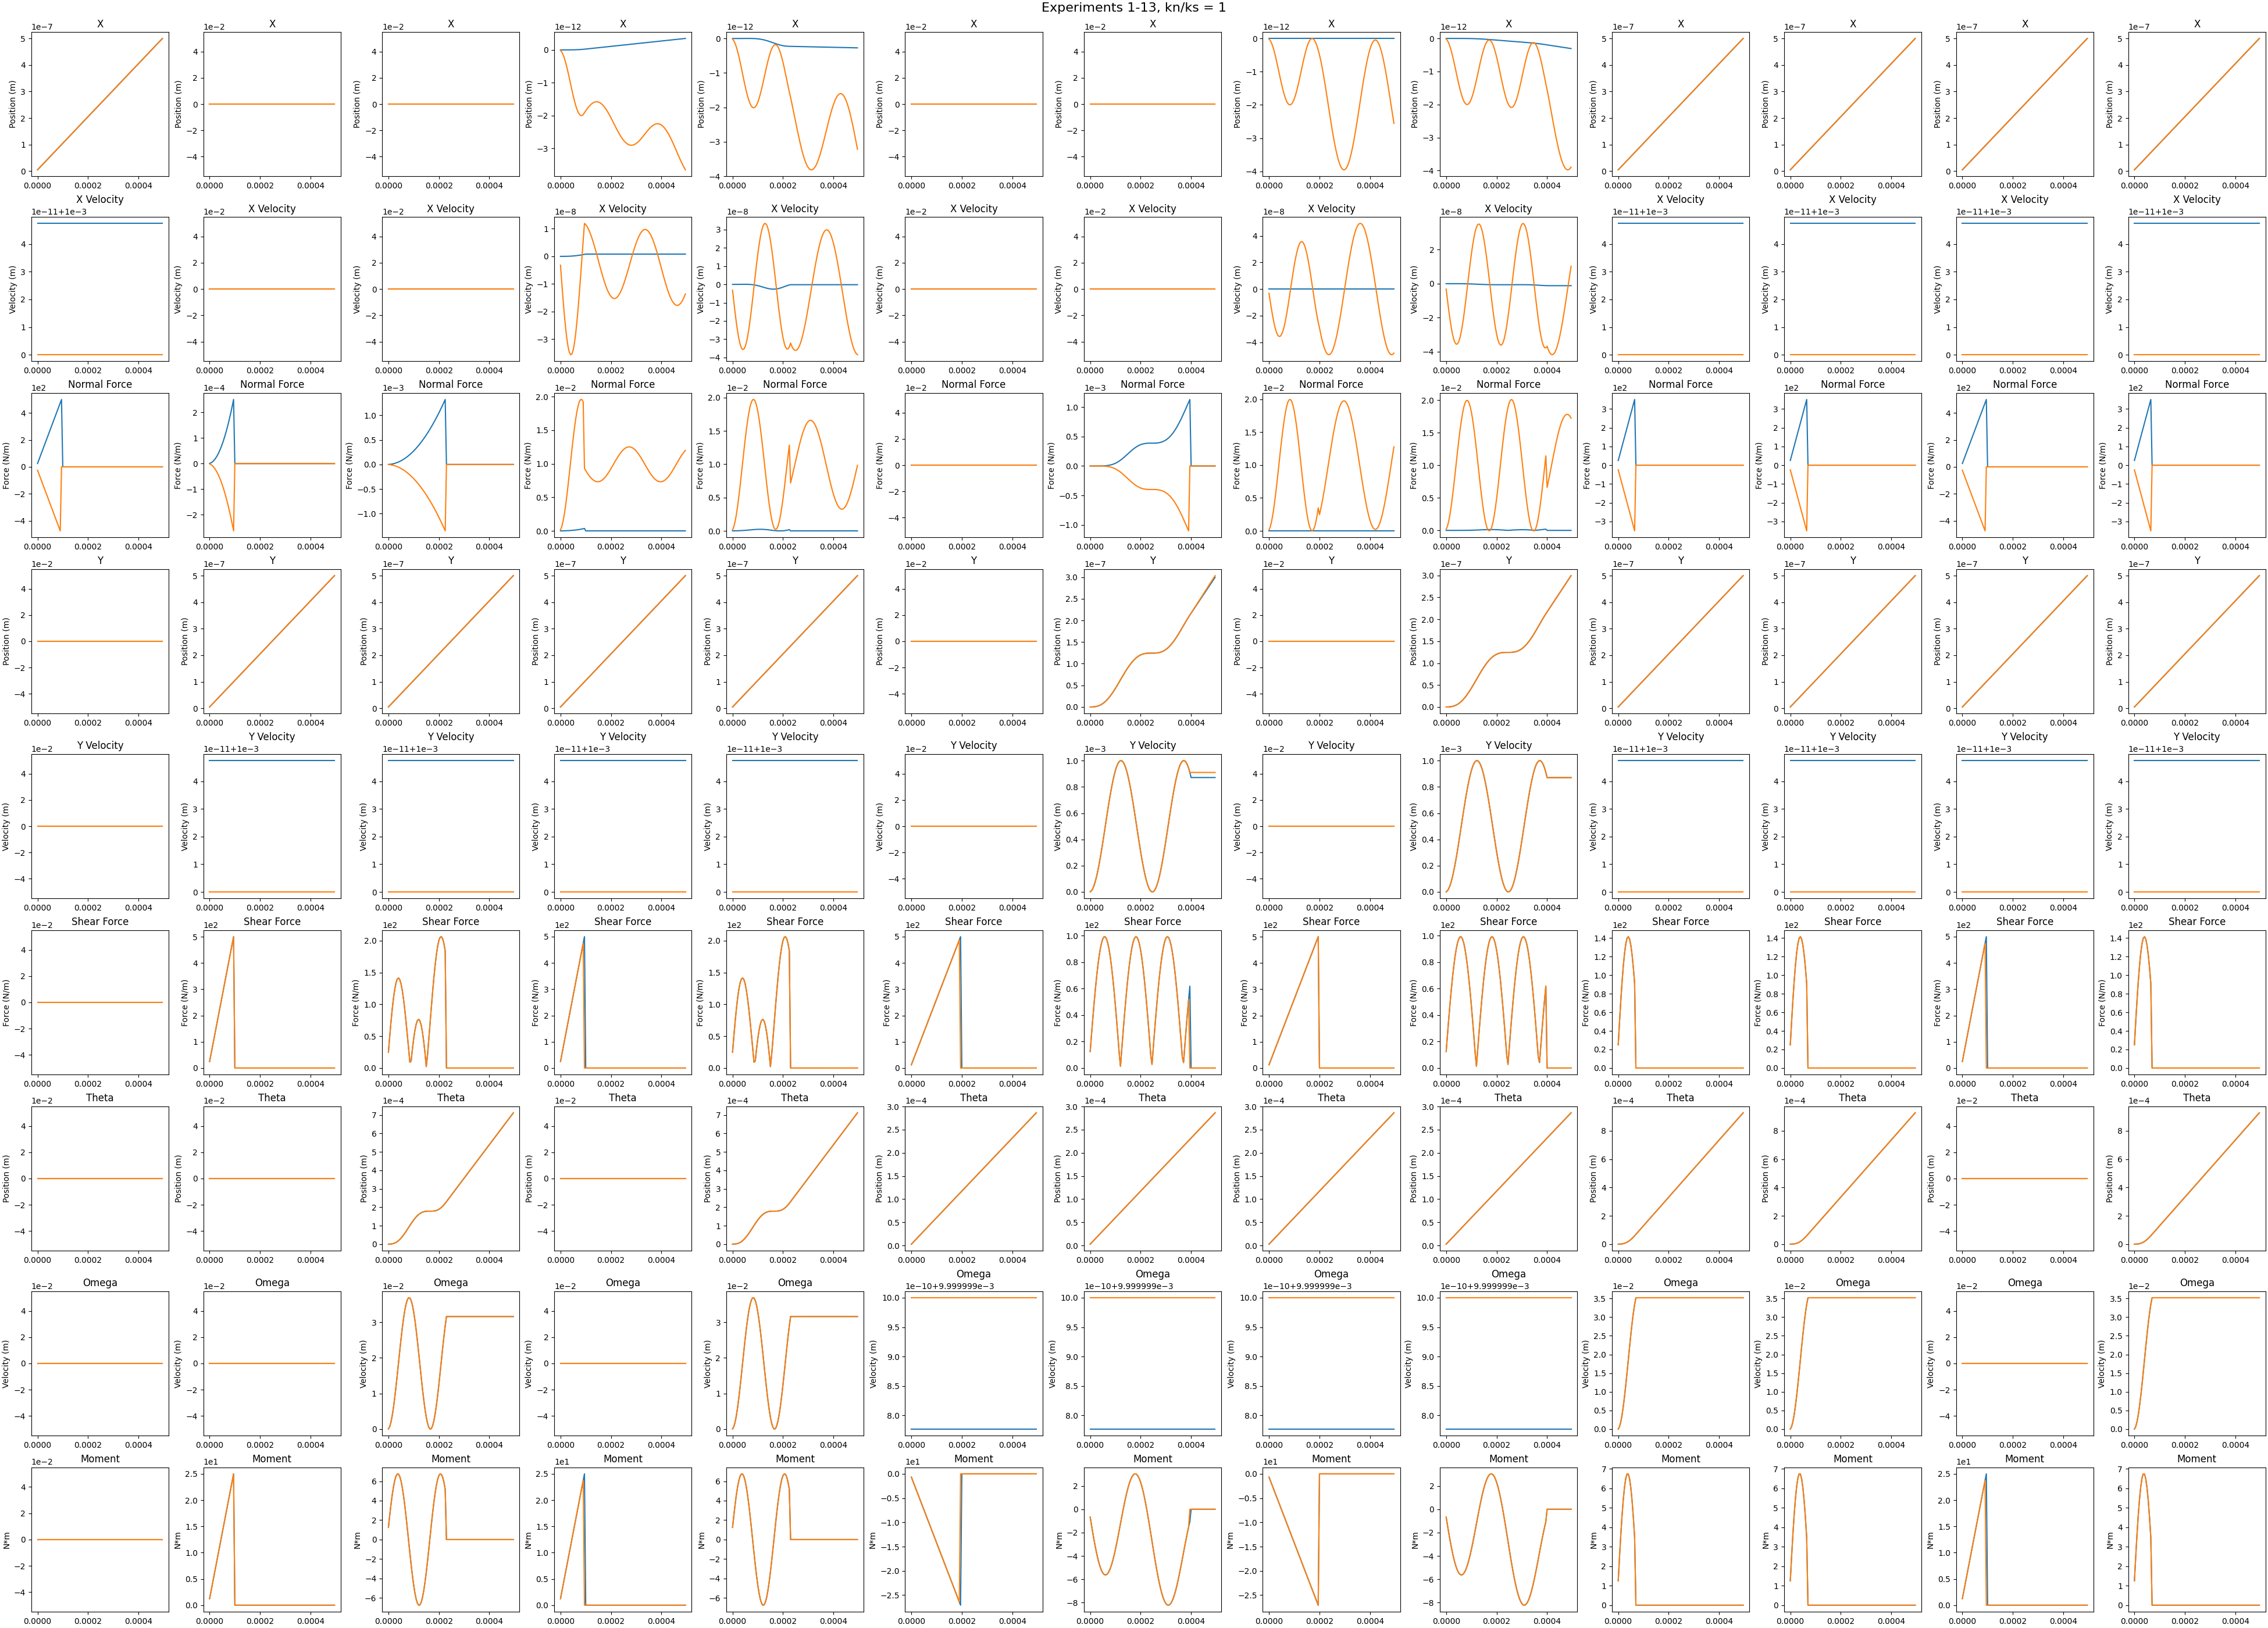

In [4]:
# getting data
# Physics Sim

bond_type = "pbt"

plt.close('all')
fig = plt.figure(figsize=(39,28), constrained_layout=True)
fig.suptitle(f'Experiments 1-{experiment}, kn/ks = {kn_ks}', fontsize=16)
gs = fig.add_gridspec(9, experiment)
mark = ""

for i in range(0,experiment):
    if bond_type == "cb":
        df = pd.read_csv(f"experiment_{i+1}_{kn_ks}.csv",delimiter=",")
    elif bond_type == "ch":
        df = pd.read_csv(f"Chain_T_{i+1}.csv",delimiter=",")
    elif bond_type == "pbt":
        df = pd.read_csv(f"TEXP_{i+1}.csv",delimiter=",")
    else: 
        df = pd.read_csv(f"{bond_type}_experiment_{i+1}_{kn_ks}.csv",delimiter=",")

    df = df.astype(float)
    
    df = df.drop(df.index[0])
    df["Timestamp"] = df["Timestamp"] - df.at[df.index[0], "Timestamp"]

    # df["Timestamp"] = df["Timestamp"] - df["Timestamp"][1]

    # PFC
    if bond_type == "pbt":
        df2 = pd.read_fwf(f"histories/pb-tear_experiment_{i+1}_{kn_ks}.his",delimiter=" ")
    elif bond_type == "ch":
        df2 = pd.read_csv(f"Chain_T_{i+1}.csv",delimiter=",")
    else:  
        df2 = pd.read_fwf(f"histories/{bond_type}-fric_experiment_{i+1}_{kn_ks}.his",delimiter=" ")
    df2 = df2.drop(df2.index[0])
    df2 = df2.astype(float)
    df2.columns = ["Step", 
                "Time(s)", 
                "x_pos", 
                "y_pos", 
                "theta", 
                "x_vel", 
                "y_vel", 
                "omega", 
                "c_nforce", 
                "c_sforce", 
                "c_moment", 
                "c_pb_stress", 
                "c_normal_y_dir", 
                "c_normal_x_dir",
                "c_pos_y",
                "c_pos_x"]
        
    df2["Time(s)"] = df2["Time(s)"] - df2.at[df2.index[0], "Time(s)"]

    # X Position
    ax1 = fig.add_subplot(gs[0, i])
    ax1.set_ylabel('Position (m)')
    ax1.plot(df["Timestamp"], df["X Position"], marker=mark)

    ax1.plot(df2["Time(s)"], df2["x_pos"])
    ax1.set_title('X')

    # X Velocity
    ax2 = fig.add_subplot(gs[1, i])
    ax2.set_ylabel('Velocity (m)')
    ax2.plot(df["Timestamp"], df["X Velocity"], marker=mark)
    ax2.plot(df2["Time(s)"], df2["x_vel"])
    ax2.set_title('X Velocity')

    # Normal Force
    ax3 = fig.add_subplot(gs[2, i])
    ax3.set_ylabel('Force (N/m)')
    ax3.plot(df["Timestamp"], df["Data1"], marker=mark)
    ax3.plot(df2["Time(s)"], df2["c_nforce"])
    ax3.set_title('Normal Force')

    # Y Position
    ax4 = fig.add_subplot(gs[3, i])
    ax4.set_ylabel('Position (m)')
    ax4.plot(df["Timestamp"], df["Y Position"], marker=mark)
    ax4.plot(df2["Time(s)"], df2["y_pos"])
    ax4.set_title('Y')

    # Y Velocity
    ax5 = fig.add_subplot(gs[4, i])
    ax5.set_ylabel('Velocity (m)')
    ax5.plot(df["Timestamp"], df["Y Velocity"], marker=mark)
    ax5.plot(df2["Time(s)"], df2["y_vel"])
    ax5.set_title('Y Velocity')

    # Shear Force
    ax6 = fig.add_subplot(gs[5, i])
    ax6.set_ylabel('Force (N/m)')
    ax6.plot(df["Timestamp"], df["Data2"].apply(abs), marker=mark)
    ax6.plot(df2["Time(s)"], df2["c_sforce"])
    ax6.set_title('Shear Force')

    # Theta
    ax7 = fig.add_subplot(gs[6, i])
    ax7.set_ylabel('Position (m)')
    ax7.plot(df["Timestamp"], df["Rotation"] * (180/3.14159), marker=mark)
    ax7.plot(df2["Time(s)"], df2["theta"])
    ax7.set_title('Theta')

    # Omega
    ax8 = fig.add_subplot(gs[7, i])
    ax8.set_ylabel('Velocity (m)')
    ax8.plot(df["Timestamp"], df["Rotation Velocity"], marker=mark)
    ax8.plot(df2["Time(s)"], df2["omega"])
    ax8.set_title('Omega')

    # Moment
    ax9 = fig.add_subplot(gs[8, i])
    ax9.set_ylabel('N*m')
    ax9.plot(df["Timestamp"], df["Data3"], marker=mark)
    ax9.plot(df2["Time(s)"], df2["c_moment"])
    ax9.set_title('Moment')

    # # Moment
    # ax10 = fig.add_subplot(gs[9, i])
    # ax10.set_ylabel('N*m')
    # ax10.plot(df["Timestamp"], df["Data3"] + df["Data1"], marker=mark)
    # ax10.set_title('Moment')

    ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax7.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax8.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax9.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    # ax10.ticklabel_format(style='sci', axis='y', scilimits=(0,0))